In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')


**Load and Explore the Data**

In [8]:
# Load the dataset
df = pd.read_csv('LIMFADD.csv')

# Display basic information about the dataset
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

print("\nColumn Names:")
print(df.columns.tolist())

print("\nTarget Variable Distribution:")
print(df['Labels'].value_counts())

Dataset Shape: (15000, 11)

First 5 rows:
   Followers  Following Following/Followers  Posts Posts/Followers  Bio  \
0          2       2757              1378.5      0               0    N   
1          2        505               252.5      0               0    N   
2       6786       1782         0.262599469   1589     6051.040404  yes   
3         21       1281                  61      0               0    N   
4        585       1682         2.875213675   2663     926.1920333  yes   

  Profile Picture External Link  Mutual Friends Threads Labels  
0               N             N               0       N    Bot  
1             Yes             N               0       N   Scam  
2               N           Yes              10       N   Real  
3             Yes             N               0       N    Bot  
4               N             N              12     Yes   Real  

Column Names:
['Followers', 'Following', 'Following/Followers', 'Posts', 'Posts/Followers', 'Bio', 'Profile Picture'

**Data Preprocessing - Handle Missing Values and Errors**

In [17]:
# Replace #DIV/0! errors with NaN
df = df.replace('#DIV/0!', np.nan)

# Convert numeric columns that might have been read as strings
numeric_columns = ['Followers', 'Following', 'Following/Followers', 'Posts', 'Posts/Followers', 'Mutual Friends']
for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Handle missing values in numeric columns by filling with median
imputer = SimpleImputer(strategy='median')
df[numeric_columns] = imputer.fit_transform(df[numeric_columns])

# Convert categorical columns (Yes/No) to binary (1/0)
categorical_columns = ['Bio', 'Profile Picture', 'External Link', 'Threads']
for col in categorical_columns:
    df[col] = df[col].map({'Yes': 1, 'N': 0, 'yes': 1})

print("Data preprocessing completed!")
print(f"Missing values after preprocessing: {df.isnull().sum().sum()}")

Data preprocessing completed!
Missing values after preprocessing: 0


**Feature Engineering**

In [18]:
# Create some new features that might be useful
df['Follower_to_Following_Ratio'] = df['Followers'] / (df['Following'] + 1)  # +1 to avoid division by zero
df['Engagement_Ratio'] = df['Posts'] / (df['Followers'] + 1)
df['Network_Score'] = df['Followers'] * df['Following'] / (df['Posts'] + 1)

# Fill any infinite values that might have been created
df = df.replace([np.inf, -np.inf], np.nan)
df = df.fillna(0)

print("Feature engineering completed!")
print(f"Total features now: {len(df.columns)}")

Feature engineering completed!
Total features now: 14


**Prepare Features and Target Variable**

In [20]:
# Encode the target variable
label_encoder = LabelEncoder()
df['Labels_Encoded'] = label_encoder.fit_transform(df['Labels'])

print("Label mapping:")
for i, label in enumerate(label_encoder.classes_):
    print(f"{i}: {label}")

# Select features for the model
feature_columns = ['Followers', 'Following', 'Following/Followers', 'Posts', 
                  'Posts/Followers', 'Bio', 'Profile Picture', 'External Link', 
                  'Mutual Friends', 'Threads', 'Follower_to_Following_Ratio', 
                  'Engagement_Ratio', 'Network_Score']

X = df[feature_columns]
y = df['Labels_Encoded']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Label mapping:
0: Bot
1: Real
2: Scam
3: Spam
Features shape: (15000, 13)
Target shape: (15000,)


**Split Data and Scale Features**

In [21]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")
print("Data splitting and scaling completed!")

Training set size: 12000
Testing set size: 3000
Data splitting and scaling completed!


**Train the Machine Learning Model**

In [22]:
# Create and train a Random Forest classifier
model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
model.fit(X_train_scaled, y_train)

print("Model training completed!")

Model training completed!


**Make Predictions and Evaluate the Model**

In [23]:
# Make predictions
y_pred = model.predict(X_test_scaled)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

# Detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

Model Accuracy: 0.9713

Classification Report:
              precision    recall  f1-score   support

         Bot       1.00      0.99      0.99       750
        Real       0.97      0.93      0.95       750
        Scam       0.99      1.00      0.99       750
        Spam       0.94      0.97      0.95       750

    accuracy                           0.97      3000
   macro avg       0.97      0.97      0.97      3000
weighted avg       0.97      0.97      0.97      3000



**Visualize the Results**

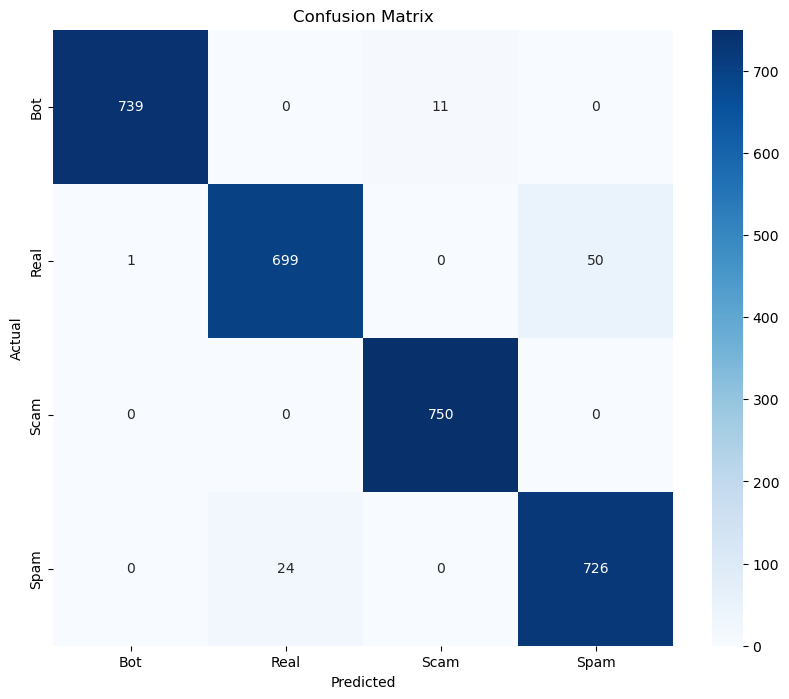

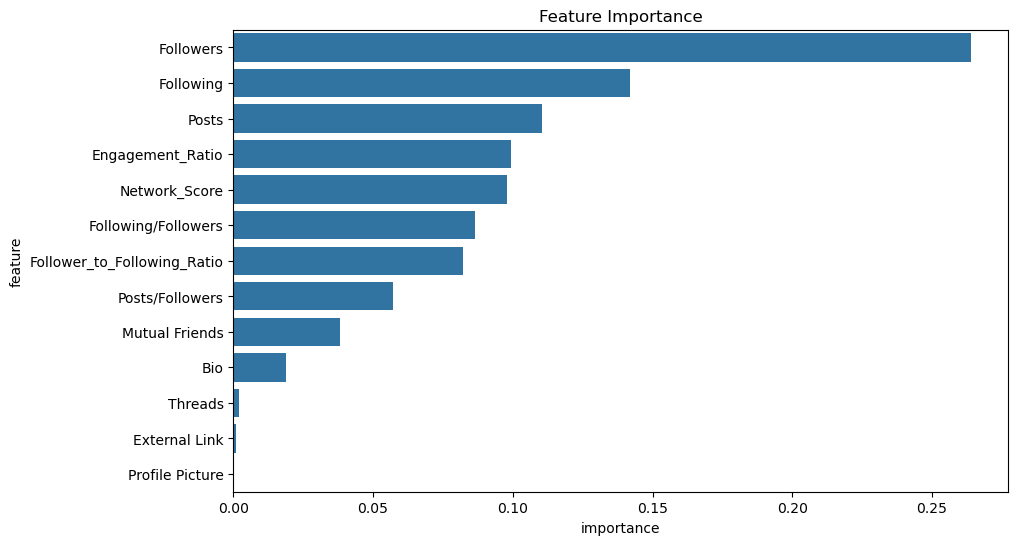

In [24]:
# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
           xticklabels=label_encoder.classes_, 
           yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Feature importance
feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='importance', y='feature')
plt.title('Feature Importance')
plt.show()

**Make Predictions on New Data**

In [25]:
# Function to predict new accounts
def predict_account(features):
    """
    Predict the type of an Instagram account
    features should be in the same order as feature_columns
    """
    features_scaled = scaler.transform([features])
    prediction_encoded = model.predict(features_scaled)[0]
    prediction_label = label_encoder.inverse_transform([prediction_encoded])[0]
    probability = model.predict_proba(features_scaled)[0]
    
    print(f"Predicted Label: {prediction_label}")
    print("Probabilities:")
    for i, label in enumerate(label_encoder.classes_):
        print(f"  {label}: {probability[i]:.4f}")
    
    return prediction_label

# Example prediction
print("Example Prediction:")
sample_features = X_test_scaled[0]  # Using first test sample as example
predict_account(sample_features)

Example Prediction:
Predicted Label: Scam
Probabilities:
  Bot: 0.0567
  Real: 0.0960
  Scam: 0.8233
  Spam: 0.0240


'Scam'

**Model Performance Summary**

In [26]:
# Final model performance summary
train_accuracy = model.score(X_train_scaled, y_train)
test_accuracy = accuracy_score(y_test, y_pred)

print("="*50)
print("MODEL PERFORMANCE SUMMARY")
print("="*50)
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")
print(f"Number of Features: {len(feature_columns)}")
print(f"Classes: {list(label_encoder.classes_)}")
print("\nTop 5 Most Important Features:")
print(feature_importance.head())

MODEL PERFORMANCE SUMMARY
Training Accuracy: 0.9915
Testing Accuracy: 0.9713
Number of Features: 13
Classes: ['Bot', 'Real', 'Scam', 'Spam']

Top 5 Most Important Features:
             feature  importance
0          Followers    0.264076
1          Following    0.142095
3              Posts    0.110495
11  Engagement_Ratio    0.099503
12     Network_Score    0.097799


**Enhanced Imports and Setup**

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("All libraries imported successfully!")

All libraries imported successfully!


**Comprehensive Data Exploration**

 COMPREHENSIVE DATA EXPLORATION
 Dataset Shape: (15000, 11)
 Columns: ['Followers', 'Following', 'Following/Followers', 'Posts', 'Posts/Followers', 'Bio', 'Profile Picture', 'External Link', 'Mutual Friends', 'Threads', 'Labels']

 Target Variable Distribution:
Labels
Bot     3750
Scam    3750
Real    3750
Spam    3750
Name: count, dtype: int64


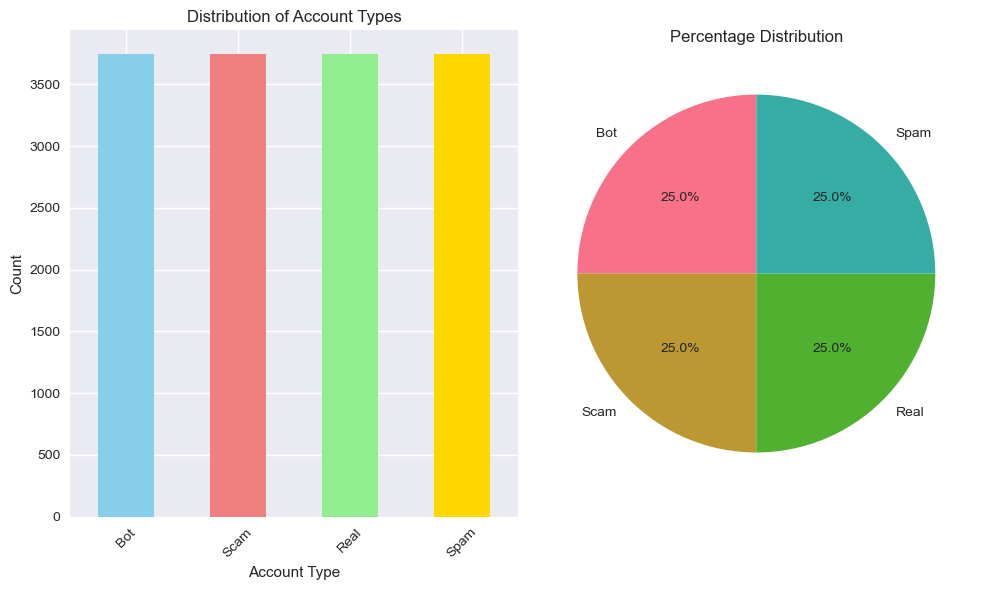


 Basic Statistics:
           Followers     Following         Posts  Mutual Friends
count   15000.000000  15000.000000  15000.000000    15000.000000
mean    23397.378933   1385.350000    427.830200        3.011733
std     41920.419061   1600.823163    678.889037        4.203313
min         0.000000      0.000000      0.000000        0.000000
25%         6.000000    369.000000      1.000000        0.000000
50%        48.000000    725.500000      4.000000        0.000000
75%     19535.250000   1747.000000    578.250000        6.000000
max    163000.000000   6692.000000   2669.000000       15.000000


In [30]:
# Load the dataset
df = pd.read_csv('LIMFADD.csv')

print(" COMPREHENSIVE DATA EXPLORATION")
print("="*50)
print(f" Dataset Shape: {df.shape}")
print(f" Columns: {df.columns.tolist()}")

print("\n Target Variable Distribution:")
label_counts = df['Labels'].value_counts()
print(label_counts)

# Visualize target distribution
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
label_counts.plot(kind='bar', color=['skyblue', 'lightcoral', 'lightgreen', 'gold'])
plt.title('Distribution of Account Types')
plt.xlabel('Account Type')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
plt.pie(label_counts.values, labels=label_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Percentage Distribution')

plt.tight_layout()
plt.show()

print(f"\n Basic Statistics:")
print(df.describe())

**Understanding Correlation Matrix**

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# Load and prepare data
df = pd.read_csv('LIMFADD.csv')
df_clean = df.copy()

# Basic cleaning
df_clean = df_clean.replace('#DIV/0!', np.nan)
numeric_cols = ['Followers', 'Following', 'Following/Followers', 'Posts', 'Posts/Followers', 'Mutual Friends']
for col in numeric_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

categorical_cols = ['Bio', 'Profile Picture', 'External Link', 'Threads']
for col in categorical_cols:
    df_clean[col] = df_clean[col].map({'Yes': 1, 'N': 0, 'yes': 1})
    df_clean[col] = df_clean[col].fillna(0).astype(int)

df_clean[numeric_cols] = df_clean[numeric_cols].fillna(df_clean[numeric_cols].median())


BASIC CORRELATION MATRIX
Correlation Matrix:
                     Followers  Following  Posts  Mutual Friends  \
Followers                1.000     -0.271  0.045           0.238   
Following               -0.271      1.000 -0.146          -0.207   
Posts                    0.045     -0.146  1.000           0.587   
Mutual Friends           0.238     -0.207  0.587           1.000   
Following/Followers     -0.176      0.386 -0.197          -0.225   
Posts/Followers          0.163     -0.077  0.054           0.060   

                     Following/Followers  Posts/Followers  
Followers                         -0.176            0.163  
Following                          0.386           -0.077  
Posts                             -0.197            0.054  
Mutual Friends                    -0.225            0.060  
Following/Followers                1.000           -0.032  
Posts/Followers                   -0.032            1.000  


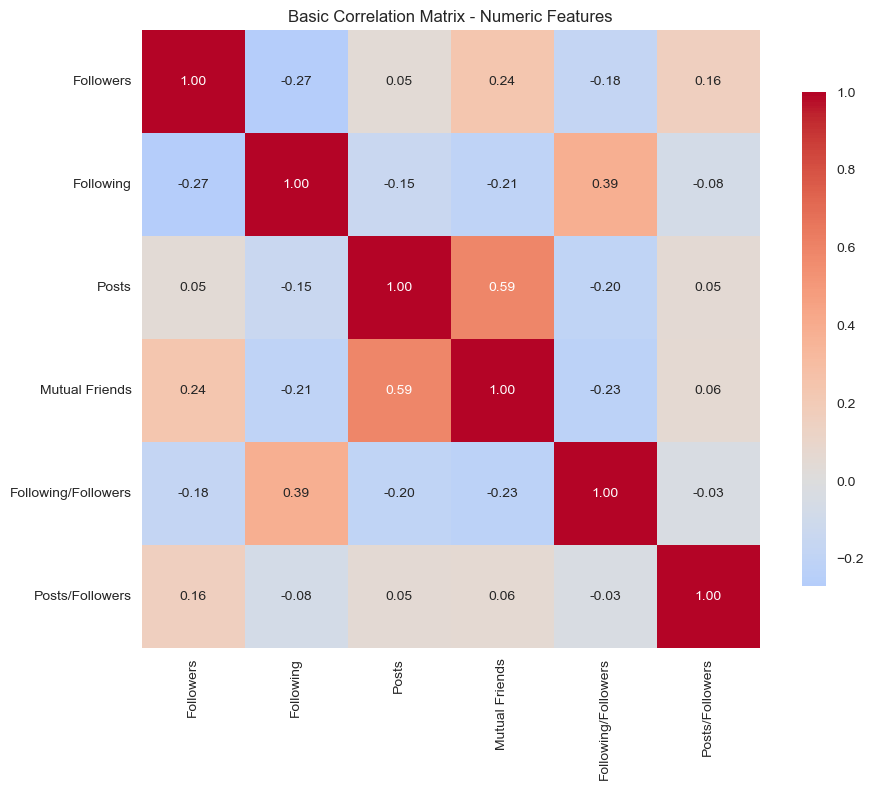

In [32]:
print("BASIC CORRELATION MATRIX")
print("="*50)

# Select numeric columns for correlation
numeric_features = ['Followers', 'Following', 'Posts', 'Mutual Friends', 'Following/Followers', 'Posts/Followers']
correlation_matrix = df_clean[numeric_features].corr()

print("Correlation Matrix:")
print(correlation_matrix.round(3))

# Visualize
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
           square=True, fmt='.2f', cbar_kws={'shrink': 0.8})
plt.title('Basic Correlation Matrix - Numeric Features')
plt.tight_layout()
plt.show()

🎯 CORRELATION WITH TARGET VARIABLE
Correlation with Target (Labels_Encoded):
Labels_Encoded         1.000
Followers              0.631
Mutual Friends         0.153
Posts/Followers        0.097
Posts                 -0.040
Following/Followers   -0.262
Following             -0.668
Name: Labels_Encoded, dtype: float64


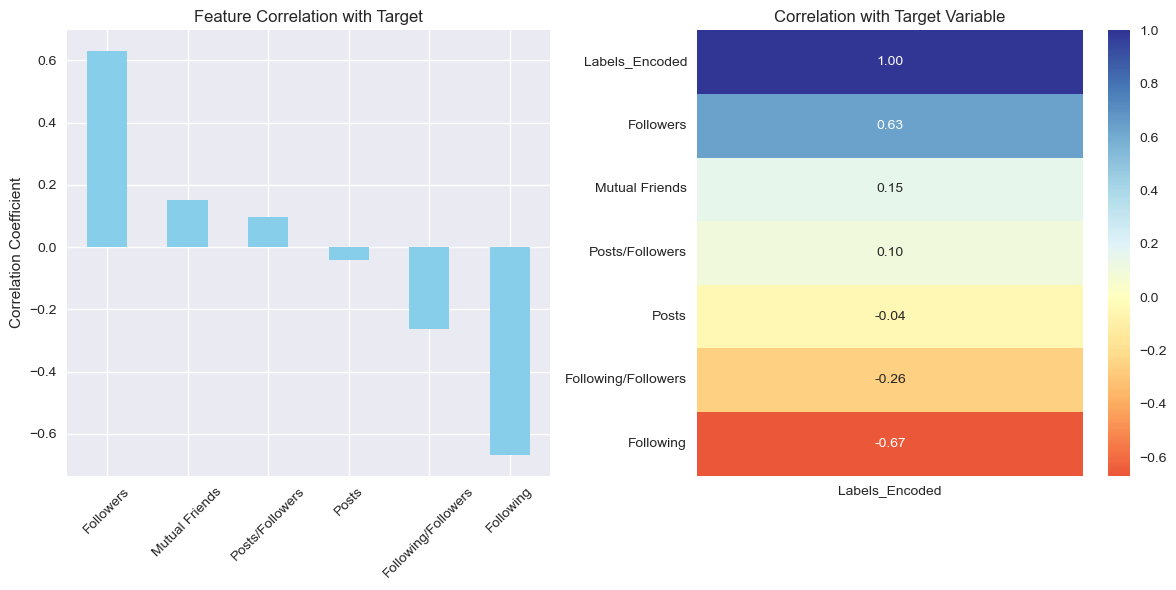

In [33]:
print(" CORRELATION WITH TARGET VARIABLE")
print("="*50)

# Encode the target variable
label_encoder = LabelEncoder()
df_clean['Labels_Encoded'] = label_encoder.fit_transform(df_clean['Labels'])

# Include target in correlation matrix
features_with_target = numeric_features + ['Labels_Encoded']
correlation_with_target = df_clean[features_with_target].corr()

print("Correlation with Target (Labels_Encoded):")
target_correlations = correlation_with_target['Labels_Encoded'].sort_values(ascending=False)
print(target_correlations.round(3))

# Visualize correlations with target
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
target_correlations.drop('Labels_Encoded').plot(kind='bar', color='skyblue')
plt.title('Feature Correlation with Target')
plt.ylabel('Correlation Coefficient')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
# Show only correlations with target
target_corr_matrix = correlation_with_target[['Labels_Encoded']].sort_values('Labels_Encoded', ascending=False)
sns.heatmap(target_corr_matrix, annot=True, cmap='RdYlBu', center=0, fmt='.2f')
plt.title('Correlation with Target Variable')

plt.tight_layout()
plt.show()